##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

YOLOv8 model loaded successfully!
Resizing layer created: 640x640 with aspect ratio padding
Image 1: Status=200, Size=121708 bytes
  Loaded — Shape: (1026, 640, 3) — Expected object: dog
Image 2: Status=200, Size=34291 bytes
  Loaded — Shape: (440, 640, 3) — Expected object: cat
Image 3: Status=200, Size=55938 bytes
  Loaded — Shape: (480, 640, 3) — Expected object: car
Image 4: Status=200, Size=55713 bytes
  Loaded — Shape: (427, 640, 3) — Expected object: bicycle
Image 5: Status=200, Size=149121 bytes
  Loaded — Shape: (960, 640, 3) — Expected object: person

Loaded 5 / 5 images


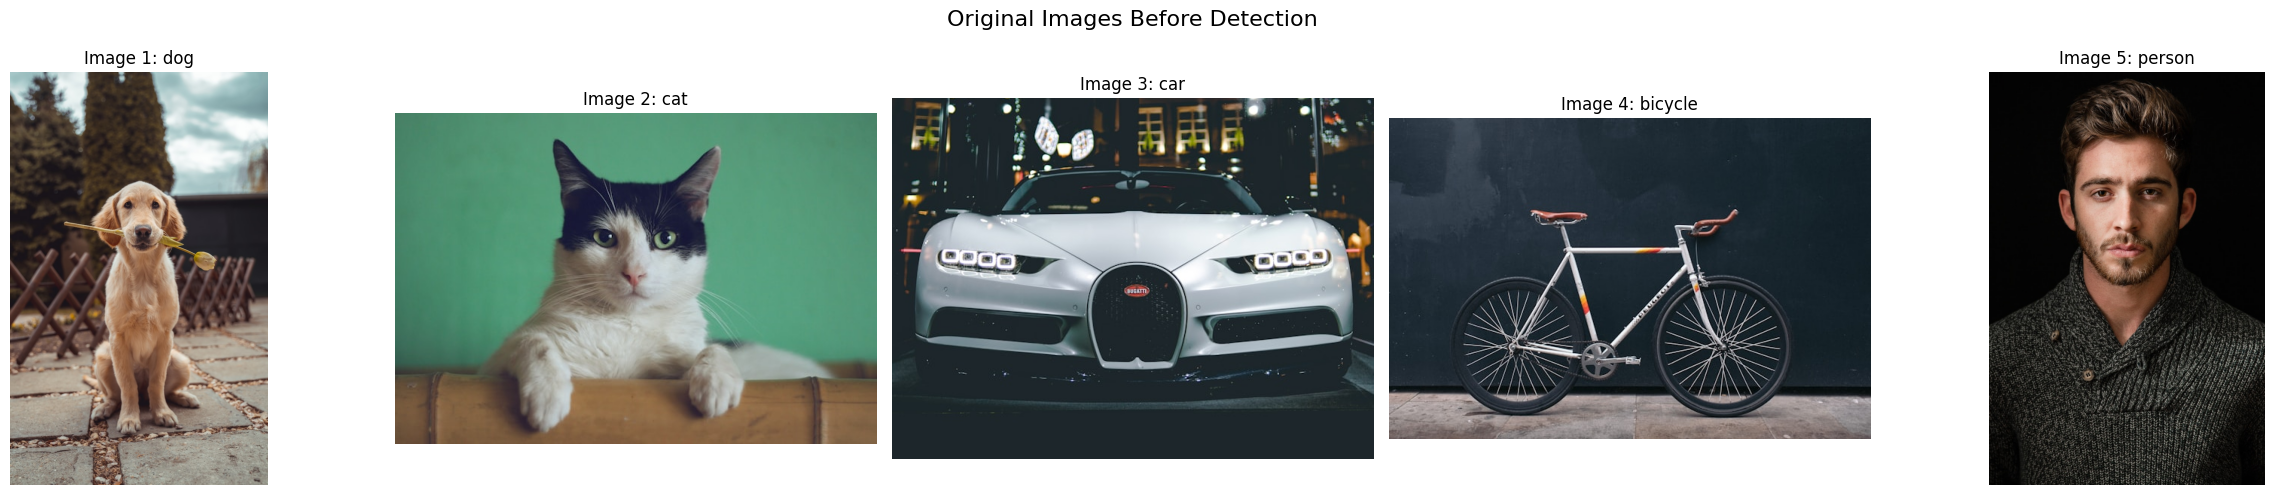


Image 1 — Expected: dog
  Detected: dog             Confidence: 96.27%
  Detected: chair           Confidence: 57.06%

Image 2 — Expected: cat
  Detected: cat             Confidence: 97.24%

Image 3 — Expected: car
  Detected: car             Confidence: 98.18%

Image 4 — Expected: bicycle
  Detected: bicycle         Confidence: 96.86%

Image 5 — Expected: person
  Detected: person          Confidence: 98.12%


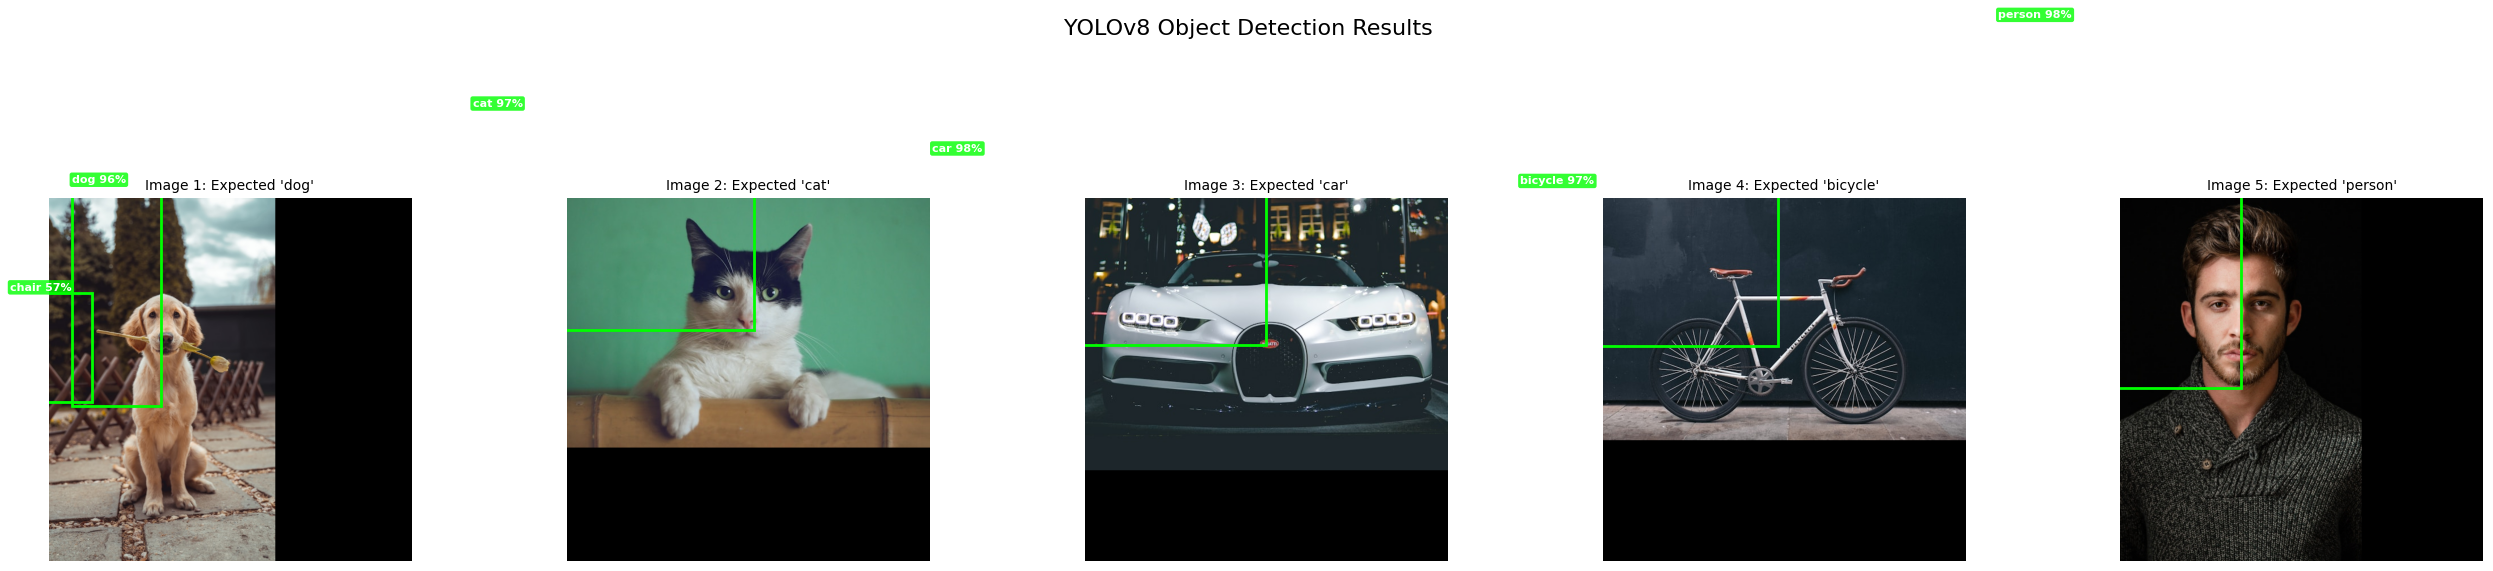


Image    Expected     Detected Objects                    Confidence      Correct?   Missed/Wrong        
1        dog          dog, chair                          96%, 57%        Yes        chair               
2        cat          cat                                 97%             Yes        None                
3        car          car                                 98%             Yes        None                
4        bicycle      bicycle                             97%             Yes        None                
5        person       person                              98%             Yes        None                


In [ ]:
# Import Libraries
import keras
import keras_cv
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# Load the pre-trained YOLOV8 model from KerasCV 
model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh",
)
print("YOLOv8 model loaded successfully!")

# Resize the images 
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)
print("Resizing layer created: 640x640 with aspect ratio padding")

# Load 5 images for different classes 
image_urls = [
    # 1. Dog
    "https://images.unsplash.com/photo-1552053831-71594a27632d?w=640",
    # 2. Cat
    "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=640",
    # 3. Car
    "https://images.unsplash.com/photo-1544636331-e26879cd4d9b?w=640",
    # 4. Bicycle
    "https://images.unsplash.com/photo-1485965120184-e220f721d03e?w=640",
    # 5. Person + Chair 
    "https://images.unsplash.com/photo-1506794778202-cad84cf45f1d?w=640",
]

# What objects we expect to find in each image
expected_objects = [
    "dog",
    "cat",
    "car",
    "bicycle",
    "person",
]

# Download and convert to numpy arrays
images = []
original_images = []  # Keep originals for display

for i, img_url in enumerate(image_urls):
    response = requests.get(img_url)
    print(f"Image {i+1}: Status={response.status_code}, Size={len(response.content)} bytes")

    if response.status_code == 200 and len(response.content) > 1000:
        img = Image.open(BytesIO(response.content)).convert("RGB")
        img_array = np.array(img)  # Convert to NumPy array
        images.append(img_array)
        original_images.append(img_array.copy())
        print(f"  Loaded — Shape: {img_array.shape} — Expected object: {expected_objects[i]}")
    else:
        print(f"  Failed to load")
        images.append(None)
        original_images.append(None)

print(f"\nLoaded {sum(1 for x in images if x is not None)} / {len(image_urls)} images")

# Display the original images before detection
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for i, img in enumerate(original_images):
    if img is not None:
        axes[i].imshow(img)
    axes[i].set_title(f"Image {i+1}: {expected_objects[i]}")
    axes[i].axis("off")
plt.suptitle("Original Images Before Detection", fontsize=16)
plt.tight_layout()
plt.show()


# Pascal VOC class names 
pascal_voc_classes = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

# Run predictions on each image
all_predictions = []

for i, img_array in enumerate(images):
    if img_array is None:
        all_predictions.append(None)
        continue

    print(f"\n{'='*60}")
    print(f"Image {i+1} — Expected: {expected_objects[i]}")
    print(f"{'='*60}")

    # Prepare image: add batch dimension and resize
    img_batch = np.expand_dims(img_array, axis=0).astype("float32")
    resized_batch = inference_resizing(img_batch)

    # Run the detector
    predictions = model.predict(resized_batch, verbose=0)
    all_predictions.append(predictions)

    # Extract results
    boxes = predictions["boxes"][0]       # Bounding boxes
    classes = predictions["classes"][0]    # Class indices
    confidence = predictions["confidence"][0]  # Confidence scores

    # Filter predictions with confidence > 0.5
    valid_mask = confidence > 0.5
    valid_boxes = boxes[valid_mask]
    valid_classes = classes[valid_mask]
    valid_confidence = confidence[valid_mask]

    if len(valid_classes) == 0:
        print("  No objects detected with confidence > 0.5")
    else:
        for j in range(len(valid_classes)):
            class_idx = int(valid_classes[j])
            class_name = pascal_voc_classes[class_idx]
            conf = float(valid_confidence[j])
            print(f"  Detected: {class_name:<15} Confidence: {conf:.2%}")

# Visualize the predictions by drawing bounding boxes and labels

fig, axes = plt.subplots(1, 5, figsize=(25, 6))

for i, img_array in enumerate(original_images):
    ax = axes[i]

    if img_array is None or all_predictions[i] is None:
        ax.set_title(f"Image {i+1}: Failed to load")
        ax.axis("off")
        continue

    # Prepare image for visualization
    img_batch = np.expand_dims(img_array, axis=0).astype("float32")
    resized_batch = inference_resizing(img_batch)

    predictions = all_predictions[i]
    boxes = predictions["boxes"][0]
    classes = predictions["classes"][0]
    confidence = predictions["confidence"][0]

    # Get the resized image for display
    display_img = resized_batch[0].numpy().astype("uint8") if hasattr(resized_batch[0], 'numpy') else resized_batch[0].astype("uint8")

    ax.imshow(display_img)

    # Draw bounding boxes for detections with confidence > 0.5
    valid_mask = confidence > 0.5
    valid_boxes = boxes[valid_mask]
    valid_classes = classes[valid_mask]
    valid_confidence = confidence[valid_mask]

    colors = plt.cm.Set3(np.linspace(0, 1, 20))

    for j in range(len(valid_classes)):
        class_idx = int(valid_classes[j])
        class_name = pascal_voc_classes[class_idx]
        conf = float(valid_confidence[j])

        # xywh format: (center_x, center_y, width, height)
        cx, cy, w, h = valid_boxes[j]
        x1 = float(cx - w / 2)
        y1 = float(cy - h / 2)

        # Draw rectangle
        rect = plt.Rectangle(
            (x1, y1), float(w), float(h),
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)

        # Add label
        ax.text(
            x1, y1 - 5,
            f"{class_name} {conf:.0%}",
            color='white', fontsize=8, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='lime', alpha=0.8, edgecolor='none')
        )

    ax.set_title(f"Image {i+1}: Expected '{expected_objects[i]}'", fontsize=10)
    ax.axis("off")

plt.suptitle("YOLOv8 Object Detection Results", fontsize=16)
plt.tight_layout()
plt.show()

# Record results for each image
print(f"\n{'Image':<8} {'Expected':<12} {'Detected Objects':<35} {'Confidence':<15} {'Correct?':<10} {'Missed/Wrong':<20}")
print("=" * 100)

for i, img_array in enumerate(images):
    if img_array is None or all_predictions[i] is None:
        print(f"{i+1:<8} {expected_objects[i]:<12} {'FAILED TO LOAD':<35} {'N/A':<15} {'N/A':<10} {'N/A':<20}")
        continue

    predictions = all_predictions[i]
    classes = predictions["classes"][0]
    confidence = predictions["confidence"][0]

    valid_mask = confidence > 0.5
    valid_classes = classes[valid_mask]
    valid_confidence = confidence[valid_mask]

    if len(valid_classes) == 0:
        detected_str = "None"
        conf_str = "N/A"
        correct = "No"
        missed = expected_objects[i]
    else:
        detected_names = [pascal_voc_classes[int(c)] for c in valid_classes]
        conf_values = [f"{float(c):.0%}" for c in valid_confidence]

        detected_str = ", ".join(detected_names)
        conf_str = ", ".join(conf_values)

        # Check if expected object was found
        correct = "Yes" if any(expected_objects[i] in name for name in detected_names) else "No"

        # Find any unexpected detections
        unexpected = [n for n in detected_names if expected_objects[i] not in n]
        missed = ", ".join(unexpected) if unexpected else "None"

    print(f"{i+1:<8} {expected_objects[i]:<12} {detected_str:<35} {conf_str:<15} {correct:<10} {missed:<20}")

